In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import ast
import seaborn as sns
import json
import glob
import random
from copy import deepcopy
from pathlib import Path
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, to_rgb, to_rgba


from Fitting_algo_v4 import *
from ECM_impedance_v3 import *
from utils import *

In [7]:
battery_json_file = "../EVC_EIS_Data/original_data/Battery_Info_DRT.json" # Check the path

with open(battery_json_file, "r") as f:
    battery_metadata = json.load(f)   # <--- this is now a dict


COLOR_MAP = build_cell_colormap(battery_metadata)

# SOH Regression

SOH ~(R0,R1,R2,R3, SOC) -- Categorical on Temperature

In [8]:
# ==========================================
# Final OLS model mirroring Lasso selection
# ==========================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# -------------------------------------------------
# 0) df must contain: SOH, R0, R1, R2, R3, SOC, Temp
#    Temp values are categorical levels (0, 25, 45)
# -------------------------------------------------
df = pd.read_csv("selectdf_global_median.csv")
print(df.shape)

# 1) Standardize continuous predictors (z-score)
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)


for col in ["R0", "R1", "R2", "R3", "SOC"]:
    df[f"{col}_z"] = zscore(df[col])

# Keep training stats to reuse on new data
train_means = {c: df[c].mean() for c in ["R0","R1","R2","R3","SOC"]}
train_stds  = {c: df[c].std(ddof=0) for c in ["R0","R1","R2","R3","SOC"]}


# 2) Build explicit dummies (25 °C is reference)
tmp = pd.get_dummies(df["Temp"].astype(int), prefix="Temp")
for need in ["Temp_0", "Temp_25", "Temp_45"]:
    if need not in tmp.columns:
        tmp[need] = 0
df = df.join(tmp[["Temp_0", "Temp_45"]])  # Temp_25 is dropped => reference group

for col in ["Temp_0","Temp_45"]:
    df[col] = df[col].astype(int)

# 3) Strict final formula 

# NOTE: Test all cross terms
final_formula_strict = (
    "SOH ~ R0_z + R1_z + R2_z + R3_z + SOC_z"
    "+ Temp_0 + Temp_45 "
    "+ R0_z:Temp_0 + R1_z:Temp_0 + R2_z:Temp_0 + R3_z:Temp_0 + SOC_z:Temp_0 "
    "+ R0_z:Temp_45 + R1_z:Temp_45 + R2_z:Temp_45 + R3_z:Temp_45 + SOC_z:Temp_45"
)

# Lasso return
# final_formula_strict = (
#     "SOH ~ R0_z + R1_z + R2_z + SOC_z"
#     "+ Temp_0"
#     "+ R0_z:Temp_0 +  R2_z:Temp_0 +  SOC_z:Temp_0 "
#     "+ R0_z:Temp_45 + R3_z:Temp_45 + SOC_z:Temp_45"
# )

# Lasso return + add back single predictor used in cross
# final_formula_strict = (
#     "SOH ~ R0_z + R1_z + R2_z + R3_z + SOC_z"
#     "+ Temp_0 + Temp_45"
#     "+ R0_z:Temp_0 +  R2_z:Temp_0 +  SOC_z:Temp_0 "
#     "+ R0_z:Temp_45 + R3_z:Temp_45 + SOC_z:Temp_45"
# )

# 4) Fit OLS
ols = smf.ols(final_formula_strict, data=df).fit()
print("\n=== OLS (classical SEs) ===")
print(ols.summary())

# Optional: robust standard errors (HC3)
ols_hc3 = ols.get_robustcov_results(cov_type="HC3")
print("\n=== OLS with robust (HC3) SEs ===")
print(ols_hc3.summary())

# 5) Read off per-temperature equations (intercepts and slopes)
p = ols.params  # coefficients as a pandas Series

# Baseline = 25 °C (Temp_0=0, Temp_45=0)
intercept_25 = p.get("Intercept", 0.0)
slopes_25 = {
    "R0_z": p.get("R0_z", 0.0),
    "R1_z": p.get("R1_z", 0.0),
    "R2_z": p.get("R2_z", 0.0),
    "R3_z": p.get("R3_z", 0.0),               # not selected at baseline
    "SOC_z": p.get("SOC_z", 0.0),              # not selected at baseline
}

# 0 °C (Temp_0=1, Temp_45=0)
intercept_0 = intercept_25 + p.get("Temp_0", 0.0)
slopes_0 = {
    "R0_z": slopes_25["R0_z"] + p.get("R0_z:Temp_0", 0.0),                         # no interaction at 0 → same as baseline
    "R1_z": slopes_25["R1_z"] + p.get("R1_z:Temp_0", 0.0),
    "R2_z": slopes_25["R2_z"] + p.get("R2_z:Temp_0", 0.0),
    "R3_z": slopes_25["R3_z"] + p.get("R3_z:Temp_0", 0.0),                                       # we intentionally dropped R3_z:Temp_0
    "SOC_z": slopes_25["SOC_z"] + p.get("SOC_z:Temp_0", 0.0),
}

# 45 °C (Temp_0=0, Temp_45=1)
intercept_45 = intercept_25 + p.get("Temp_45", 0.0)
slopes_45 = {
    "R0_z": slopes_25["R0_z"] + p.get("R0_z:Temp_45", 0.0),
    "R1_z": slopes_25["R1_z"] + p.get("R1_z:Temp_45", 0.0),                         # no R1_z:Temp_45 term
    "R2_z": slopes_25["R2_z"] + p.get("R2_z:Temp_45", 0.0),
    "R3_z": slopes_25["R3_z"] + p.get("R3_z:Temp_45", 0.0),
    "SOC_z": slopes_25["SOC_z"] + p.get("SOC_z:Temp_45", 0.0),
}

print("\n--- Per-temperature linear forms (in z-scored predictors) ---")
print(f"Temp=25°C: SOH = {intercept_25:+.4f}"
      f" + {slopes_25['R0_z']:+.4f}*R0_z"
      f" + {slopes_25['R1_z']:+.4f}*R1_z"
      f" + {slopes_25['R2_z']:+.4f}*R2_z"
      f" + {slopes_25['R3_z']:+.4f}*R3_z"
      f" + {slopes_25['SOC_z']:+.4f}*SOC_z")

print(f"Temp=0°C:  SOH = {intercept_0:+.4f}"
      f" + {slopes_0['R0_z']:+.4f}*R0_z"
      f" + {slopes_0['R1_z']:+.4f}*R1_z"
      f" + {slopes_0['R2_z']:+.4f}*R2_z"
      f" + {slopes_0['R3_z']:+.4f}*R3_z"
      f" + {slopes_0['SOC_z']:+.4f}*SOC_z")

print(f"Temp=45°C: SOH = {intercept_45:+.4f}"
      f" + {slopes_45['R0_z']:+.4f}*R0_z"
      f" + {slopes_45['R1_z']:+.4f}*R1_z"
      f" + {slopes_45['R2_z']:+.4f}*R2_z"
      f" + {slopes_45['R3_z']:+.4f}*R3_z"
      f" + {slopes_45['SOC_z']:+.4f}*SOC_z")

# 6) Predict on new data (make sure you have the same columns!)
# Example: predict on the training df itself
df["_pred_OLS"] = ols.predict(df)
train_pred = ols.get_prediction(df)
train_sf   = train_pred.summary_frame(alpha=0.05)
df["_pred_OLS_mean_ci_lower"] = train_sf["mean_ci_lower"].values
df["_pred_OLS_mean_ci_upper"] = train_sf["mean_ci_upper"].values

# Choose ONE of the two blocks below:

# (A) 95% Confidence Interval for the MEAN response:
# df["_ci_low"]  = train_sf["mean_ci_lower"].values
# df["_ci_high"] = train_sf["mean_ci_upper"].values

# # (B) 95% Prediction Interval for an INDIVIDUAL observation:
df["_ci_low"]  = train_sf["obs_ci_lower"].values
df["_ci_high"] = train_sf["obs_ci_upper"].values

# error bar distances above/below the point (asymmetric allowed)
df["_yerr_low"]  = (df["_pred_OLS"] - df["_ci_low"]).clip(lower=0)
df["_yerr_high"] = (df["_ci_high"] - df["_pred_OLS"]).clip(lower=0)
df.to_csv("selectdf_global_median_with_preds.csv", index=False)

mask = df["SOH"].notna() & df["_pred_OLS"].notna()
if mask.any():
    y_true = df.loc[mask, "SOH"]
    y_pred = df.loc[mask, "_pred_OLS"]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # in %

    print("\n=== Model Performance ===")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"MAPE = {mape:.2f}%")



# 7) Helper to prepare ANY new dataframe using TRAINING stats
def prepare_new_rows(raw_df):
    out = raw_df.copy()

    # Ensure numeric types
    for c in ["R0","R1","R2","R3","SOC","Temp"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    # z-scores using TRAINING means/stds
    for c in ["R0","R1","R2","R3","SOC"]:
        out[f"{c}_z"] = (out[c] - train_means[c]) / train_stds[c]

    # Temp dummies (align to training design: 25°C reference)
    tmp_new = pd.get_dummies(out["Temp"].astype("Int64"), prefix="Temp")
    for need in ["Temp_0","Temp_25","Temp_45"]:
        if need not in tmp_new.columns:
            tmp_new[need] = 0
    out = out.join(tmp_new[["Temp_0","Temp_45"]])
    out["Temp_0"]  = out["Temp_0"].fillna(0).astype(int)
    out["Temp_45"] = out["Temp_45"].fillna(0).astype(int)

    return out

# 8) Load new data and predict
new_df = pd.read_csv("selectdf_global_all.csv")

new_prepared = prepare_new_rows(new_df)
new_df["_pred_OLS_mean"] = ols.predict(new_prepared)

# (Optional) prediction intervals on new data (95% by default)
pred_res = ols.get_prediction(new_prepared)
pred_sf  = pred_res.summary_frame(alpha=0.05)  # columns: mean, mean_ci_lower/upper, obs_ci_lower/upper
new_df["_pred_OLS_mean_ci_lower"] = pred_sf["mean_ci_lower"].values
new_df["_pred_OLS_mean_ci_upper"] = pred_sf["mean_ci_upper"].values
new_df["_pred_OLS_obs_ci_lower"]  = pred_sf["obs_ci_lower"].values
new_df["_pred_OLS_obs_ci_upper"]  = pred_sf["obs_ci_upper"].values

# 9) (Optional) if SOH present in global_all.csv, evaluate quickly
if "SOH" in new_df.columns:
    from sklearn.metrics import r2_score, mean_absolute_error
    mask = new_df["_pred_OLS_mean"].notna() & new_df["SOH"].notna()
    if mask.any():
        r2  = r2_score(new_df.loc[mask,"SOH"], new_df.loc[mask,"_pred_OLS_mean"])
        mae = mean_absolute_error(new_df.loc[mask,"SOH"], new_df.loc[mask,"_pred_OLS_mean"])
        rmse = np.sqrt(mean_squared_error(new_df.loc[mask,"SOH"], new_df.loc[mask,"_pred_OLS_mean"]))
        mape = np.mean(np.abs((new_df.loc[mask,"SOH"] - new_df.loc[mask,"_pred_OLS_mean"]) / new_df.loc[mask,"SOH"])) * 100  # in %

        print("\n=== Model Performance (Test) ===")
        print(f"MAE  = {mae:.4f}")
        print(f"RMSE = {rmse:.4f}")
        print(f"MAPE = {mape:.2f}%")

# 8) Save predictions
new_df.to_csv("selectdf_with_ols_preds.csv", index=False)
print("\nSaved predictions to selectdf_with_ols_preds.csv")

(235, 16)

=== OLS (classical SEs) ===
                            OLS Regression Results                            
Dep. Variable:                    SOH   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     285.3
Date:                Tue, 04 Nov 2025   Prob (F-statistic):          4.43e-138
Time:                        17:34:49   Log-Likelihood:                 218.16
No. Observations:                 235   AIC:                            -400.3
Df Residuals:                     217   BIC:                            -338.0
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Interce

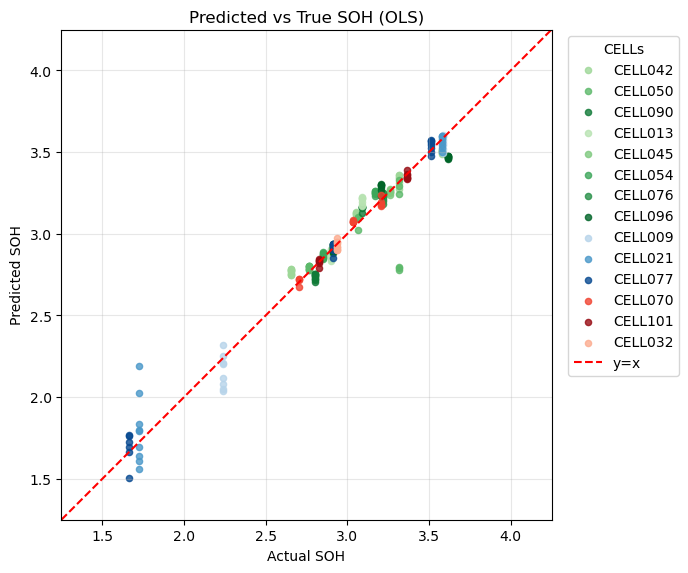

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

# scatter by cell
for cell in df["CELL"].unique():   # <-- adjust column name if it's different
    sub = df[df["CELL"] == cell]
    plt.scatter(
        sub["SOH"], sub["_pred_OLS"],
        alpha=0.8, s=20, label=cell, color=COLOR_MAP[cell]
    )

# plt.scatter(g["SOH"], g["SOH_hat"], label=cell, alpha=0.8, s=30, color=COLOR_MAP[cell])

# 45° reference line
# lims = [min(df["SOH"].min(), df["_pred_OLS"].min()),
#         max(df["SOH"].max(), df["_pred_OLS"].max())]
plt.plot([1.25,4.25], [1.25,4.25], "r--",  label="y=x")

plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("Predicted vs True SOH (OLS)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="CELLs")  # put legend outside
plt.grid(alpha=0.3)
plt.axis("equal")
plt.tight_layout()
plt.axis('square')
plt.xlim(1.25, 4.25)
plt.ylim(1.25, 4.25)
plt.show()


In [9]:
df_fetch = df.copy()

print(df_fetch.loc[df["CELL"] == "CELL021", ["CELL", "SOH", "_pred_OLS", "SOC"]].sort_values(by="_pred_OLS", ascending=False))

        CELL      SOH  _pred_OLS       SOC
169  CELL021  3.58134   3.597050  0.329646
168  CELL021  3.58134   3.596668  0.413199
167  CELL021  3.58134   3.589336  0.496745
166  CELL021  3.58134   3.577291  0.580377
165  CELL021  3.58134   3.562114  0.663956
164  CELL021  3.58134   3.544849  0.747579
163  CELL021  3.58134   3.524965  0.831153
162  CELL021  3.58134   3.498705  0.914789
170  CELL021  1.72403   2.188913  0.938268
171  CELL021  1.72403   2.026743  0.876479
173  CELL021  1.72403   1.834688  0.752971
174  CELL021  1.72403   1.801248  0.691253
172  CELL021  1.72403   1.792609  0.814727
175  CELL021  1.72403   1.697236  0.629537
176  CELL021  1.72403   1.638781  0.567822
177  CELL021  1.72403   1.606732  0.506084
178  CELL021  1.72403   1.558699  0.444360


Testset:

(21935, 21)


C:\Users\liuha\AppData\Local\Temp\ipykernel_3624\2657001827.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([lo, hi], [lo, hi], "r--", lw=1, color="red", label="y=x")


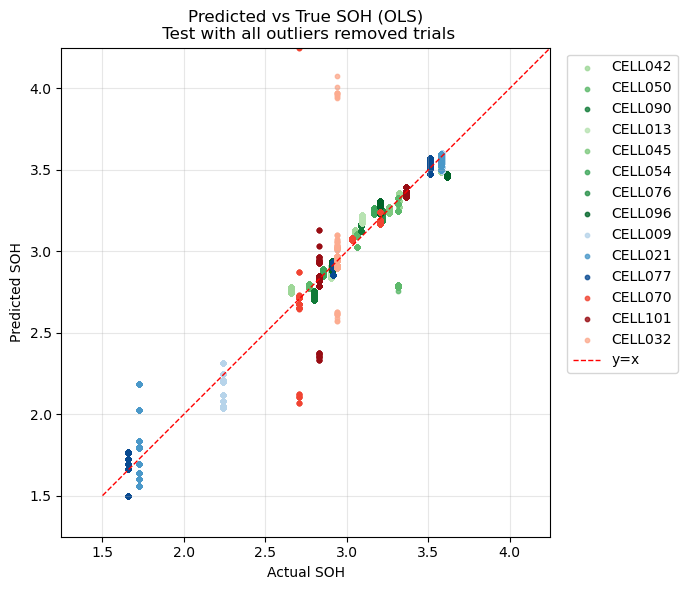

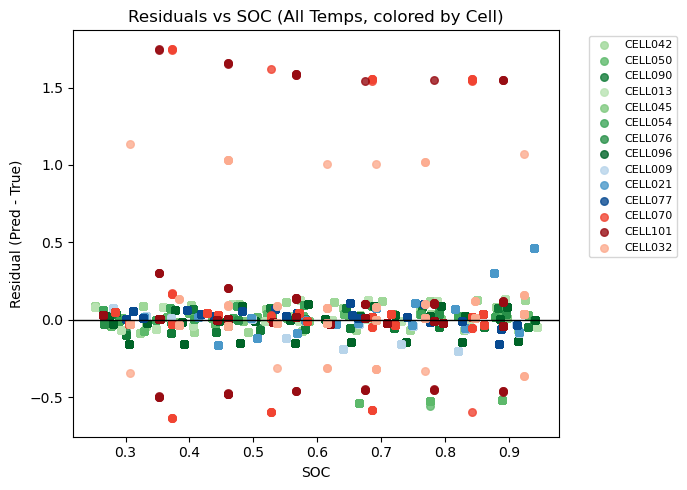

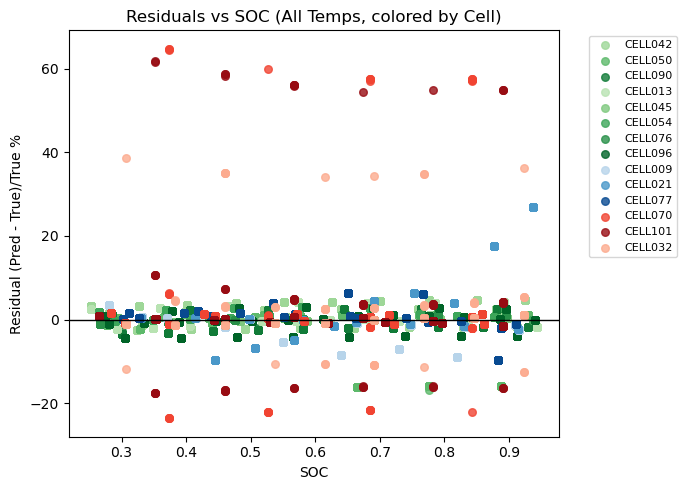

Test metrics — R^2: 0.9358, MAE: 0.0644
Saved annotated data with residuals to global_all_with_visualization_fields.csv


In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from typing import Optional

def load_testing_dataframe() -> Optional[pd.DataFrame]:
    if os.path.exists("selectdf_with_ols_preds.csv"):
        return pd.read_csv("selectdf_with_ols_preds.csv")
    if os.path.exists("selectdf_global_all.csv"):
        return pd.read_csv("selectdf_global_all.csv")
    return None

df = load_testing_dataframe()
print(df.shape)


if df is None:
    print("Could not find 'global_all_with_ols_preds.csv' or 'global_all.csv'.")
else:
    pred_col_candidates = ["_pred_OLS_mean", "pred", "prediction", "y_pred"]
    gt_col_candidates   = ["SOH", "y", "target"]
    temp_col_candidates = ["Temp", "temperature", "temp"]
    soc_col_candidates  = ["SOC", "soc"]

    pred_col = next((c for c in pred_col_candidates if c in df.columns), None)
    gt_col   = next((c for c in gt_col_candidates if c in df.columns), None)
    temp_col = next((c for c in temp_col_candidates if c in df.columns), None)
    soc_col  = next((c for c in soc_col_candidates if c in df.columns), None)

    if pred_col is None:
        print("No prediction column found.")
    else:
        if gt_col is not None:
            df["_residual"] = df[pred_col] - df[gt_col]
            df["rel_residual"] = (df[pred_col] - df[gt_col])/df[gt_col] *100


        # 1) plot with colors by CELL
        if gt_col is not None and "CELL" in df.columns:
            plt.figure(figsize=(10,6))
            for cell in df["CELL"].unique():
                sub = df[df["CELL"] == cell]
                plt.scatter(
                    sub[gt_col], sub[pred_col],
                    alpha=0.8, s=10,
                    label=cell,
                    color=COLOR_MAP.get(cell, "gray")
                )
            lo = min(df[gt_col].min(), df[pred_col].min())
            hi = max(df[gt_col].max(), df[pred_col].max())
            plt.plot([lo, hi], [lo, hi], "r--", lw=1, color="red", label="y=x")

            plt.xlabel("Actual SOH")
            plt.ylabel("Predicted SOH")
            plt.title("Predicted vs True SOH (OLS)\n Test with all outliers removed trials")
            plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.axis('square')
            plt.xlim(1.25, 4.25)
            plt.ylim(1.25, 4.25)

            plt.show()

        # 2) Residuals vs SOC (colored by CELL)
        if gt_col is not None and soc_col is not None and "_residual" in df.columns and "CELL" in df.columns:
            plt.figure(figsize=(7,5))
            for cell in df["CELL"].unique():
                sub = df[df["CELL"] == cell]
                plt.scatter(
                    sub[soc_col], sub["_residual"],
                    alpha=0.8, s=30,
                    label=cell,
                    color=COLOR_MAP.get(cell, "gray")
                )
            plt.axhline(0, color="black", lw=1)
            plt.xlabel("SOC")
            plt.ylabel("Residual (Pred - True)")
            plt.title("Residuals vs SOC (All Temps, colored by Cell)")
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
            plt.tight_layout()
            plt.show()

        # 3) Relative Residuals vs SOC (colored by CELL)
        if gt_col is not None and soc_col is not None and "_residual" in df.columns and "CELL" in df.columns:
            plt.figure(figsize=(7,5))
            for cell in df["CELL"].unique():
                sub = df[df["CELL"] == cell]
                plt.scatter(
                    sub[soc_col], sub["rel_residual"],
                    alpha=0.8, s=30,
                    label=cell,
                    color=COLOR_MAP.get(cell, "gray")
                )
            plt.axhline(0, color="black", lw=1)
            plt.xlabel("SOC")
            plt.ylabel("Residual (Pred - True)/True %")
            plt.title("Residuals vs SOC (All Temps, colored by Cell)")
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
            plt.tight_layout()
            plt.show()

        # You can still keep per-temperature residual plots & boxplots as before
        # (color them by CELL inside each temp group similarly if desired)

        # Quick metrics
        if gt_col is not None:
            from sklearn.metrics import r2_score, mean_absolute_error
            mask = df[pred_col].notna() & df[gt_col].notna()
            if mask.any():
                r2  = r2_score(df.loc[mask, gt_col], df.loc[mask, pred_col])
                mae = mean_absolute_error(df.loc[mask, gt_col], df.loc[mask, pred_col])
                print(f"Test metrics — R^2: {r2:.4f}, MAE: {mae:.4f}")

    if "_residual" in df.columns:
        out_path = "global_all_with_visualization_fields.csv"
        df.to_csv(out_path, index=False)
        print(f"Saved annotated data with residuals to {out_path}")


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Make a tidy dataframe from your dicts
slopes_df = pd.DataFrame([
    {"Predictor": k.replace("_z",""), "Temp": 25, "Coef_Value": v}
    for k, v in slopes_25.items()
] + [
    {"Predictor": k.replace("_z",""), "Temp": 0, "Coef_Value": v}
    for k, v in slopes_0.items()
] + [
    {"Predictor": k.replace("_z",""), "Temp": 45, "Coef_Value": v}
    for k, v in slopes_45.items()
])

print(slopes_df)

fig_dir = "SOH_Regression_Plots"
os.makedirs(fig_dir, exist_ok=True)

# Plot slope vs temperature for each predictor
for pred in slopes_df["Predictor"].unique():
    sub = slopes_df.query("Predictor == @pred").sort_values("Temp")
    plt.figure()
    plt.plot(sub["Temp"], sub["Coef_Value"], marker="o")
    # dashed line between first and last temperature point
    if len(sub) >= 2:
        t0, t1 = sub["Temp"].iloc[0], sub["Temp"].iloc[-1]
        s0, s1 = sub["Coef_Value"].iloc[0], sub["Coef_Value"].iloc[-1]
        plt.plot([t0, t1], [s0, s1], "k--", label=f"{t0}→{t1} trend")
    plt.title(f"Coefficient of {pred} vs Temperature")
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Coefficient")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks([0,25,45])
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/coef_vs_temp_{pred}.png", dpi=150)
    plt.close()


# --- Build tidy dataframe for intercepts (ordered 0 -> 25 -> 45) ---
intercepts_df = pd.DataFrame([
    {"Term": "Intercept", "Temp": 0,  "Coef_Value": intercept_0},
    {"Term": "Intercept", "Temp": 25, "Coef_Value": intercept_25},
    {"Term": "Intercept", "Temp": 45, "Coef_Value": intercept_45},
]).sort_values("Temp")


print(intercepts_df)

# --- Plot intercept vs temperature ---
plt.figure()
plt.plot(intercepts_df["Temp"], intercepts_df["Coef_Value"], marker="o", label="Intercept")

# dashed line connecting first and last
t0, t1 = intercepts_df["Temp"].iloc[0], intercepts_df["Temp"].iloc[-1]
s0, s1 = intercepts_df["Coef_Value"].iloc[0], intercepts_df["Coef_Value"].iloc[-1]
plt.plot([t0, t1], [s0, s1], "k--", label=f"{t0}→{t1} trend")

plt.title("Intercept vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Intercept")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks([0, 25, 45])
plt.tight_layout()
plt.savefig(f"{fig_dir}/intercept_vs_temp.png", dpi=150)
plt.close()


   Predictor  Temp  Coef_Value
0         R0    25   -0.142931
1         R1    25   -0.217108
2         R2    25   -0.284689
3         R3    25    0.010645
4        SOC    25    0.003408
5         R0     0   -0.289582
6         R1     0    0.059721
7         R2     0   -0.912037
8         R3     0   -0.514787
9        SOC     0   -0.049338
10        R0    45   -0.880921
11        R1    45   -0.161663
12        R2    45   -0.256681
13        R3    45    0.206228
14       SOC    45   -0.002889
        Term  Temp  Coef_Value
0  Intercept     0    1.903713
1  Intercept    25    3.003712
2  Intercept    45    2.780066


In [12]:
import matplotlib.ticker as mticker
# --- Combine slopes and intercept into one tidy df ---
slopes_df2 = slopes_df.rename(columns={"Slope": "Coef_Value"})
all_effects_df = pd.concat([slopes_df2, intercepts_df.rename(columns={"Term": "Predictor"})],
                           ignore_index=True)
all_effects_df.insert(2, "K", (273.15 + all_effects_df["Temp"]))
all_effects_df.insert(3, "1/K", 1.0 / (273.15 + all_effects_df["Temp"]))
all_effects_df.insert(4, "EXP(1/K)", np.exp(1.0 / (273.15 + all_effects_df["Temp"])))



print(all_effects_df)
all_effects_df.to_csv("all_effects_vs_temp.csv", index=False)


fig_dir = "SOH_Regression_Plots"
os.makedirs(fig_dir, exist_ok=True)
# --- Plot all predictors + intercept together ---
plt.figure(figsize=(8,6))
for pred in all_effects_df["Predictor"].unique():
    sub = all_effects_df.query("Predictor == @pred").sort_values("Temp")
    plt.plot(sub["Temp"], sub["Coef_Value"], marker="o", label=pred)
  

plt.title("Coefficients vs Temperature (Predictors + Intercept)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Coefficient Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks([0,25,45])
plt.ylim(-3.1, 3.1)
plt.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/coef_vs_temp_all.png", dpi=150)
plt.close()


# --- Plot all predictors + intercept together ---
plt.figure(figsize=(8,6))
for pred in all_effects_df["Predictor"].unique():
    sub = all_effects_df.query("Predictor == @pred").sort_values("1/K")
    plt.plot(sub["1/K"], sub["Coef_Value"], marker="o", label=pred)
  

plt.title("Coefficients vs Temperature (Predictors + Intercept)")
plt.xlabel("Temperature (1/K)")
plt.ylabel("Coefficient Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/coef_vs_tempK_all.png", dpi=150)
plt.close()


# --- Plot all predictors + intercept together ---
plt.figure(figsize=(8,6))
for pred in all_effects_df["Predictor"].unique():
    sub = all_effects_df.query("Predictor == @pred").sort_values("1/K")
    plt.plot(sub["1/K"], sub["Coef_Value"], marker="o", label=pred)
  

plt.title("Coefficients vs Temperature (Predictors + Intercept)")
plt.xlabel("Temperature (1/K)")
plt.ylabel("Coefficient Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/coef_vs_temp_1overK_all.png", dpi=150)
plt.close()


# --- Plot all predictors + intercept together ---
plt.figure(figsize=(8,6))
for pred in all_effects_df["Predictor"].unique():
    sub = all_effects_df.query("Predictor == @pred").sort_values("K")
    plt.plot(sub["K"], sub["Coef_Value"], marker="o", label=pred)
  

plt.title("Coefficients vs Temperature (Predictors + Intercept)")
plt.xlabel("Temperature (K)")
plt.ylabel("Coefficient Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/coef_vs_tempK_all.png", dpi=150)
plt.close()


# --- Plot all predictors + intercept together ---
plt.figure(figsize=(8,6))
for pred in all_effects_df["Predictor"].unique():
    sub = all_effects_df.query("Predictor == @pred").sort_values("EXP(1/K)")
    plt.plot(sub["EXP(1/K)"], sub["Coef_Value"], marker="o", label=pred)
  

plt.title("Coefficients vs Temperature (Predictors + Intercept)")
plt.xlabel("Temperature (EXP(1/K))")
plt.ylabel("Coefficient Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
# Format ticks nicely: let matplotlib choose tick spacing, but show 4 decimals
plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
plt.savefig(f"{fig_dir}/coef_vs_temp_exp1overK_all.png", dpi=150)
plt.close()



    Predictor  Temp       K       1/K  EXP(1/K)  Coef_Value
0          R0    25  298.15  0.003354  1.003360   -0.142931
1          R1    25  298.15  0.003354  1.003360   -0.217108
2          R2    25  298.15  0.003354  1.003360   -0.284689
3          R3    25  298.15  0.003354  1.003360    0.010645
4         SOC    25  298.15  0.003354  1.003360    0.003408
5          R0     0  273.15  0.003661  1.003668   -0.289582
6          R1     0  273.15  0.003661  1.003668    0.059721
7          R2     0  273.15  0.003661  1.003668   -0.912037
8          R3     0  273.15  0.003661  1.003668   -0.514787
9         SOC     0  273.15  0.003661  1.003668   -0.049338
10         R0    45  318.15  0.003143  1.003148   -0.880921
11         R1    45  318.15  0.003143  1.003148   -0.161663
12         R2    45  318.15  0.003143  1.003148   -0.256681
13         R3    45  318.15  0.003143  1.003148    0.206228
14        SOC    45  318.15  0.003143  1.003148   -0.002889
15  Intercept     0  273.15  0.003661  1

## Single Temp Regression

In [32]:
# -------------------------------------------------
# Load data (must contain SOH, R0, R1, R2, R3, SOC)
# -------------------------------------------------
df = pd.read_csv("selectdf_global_median.csv")
# Select single Temperature
df = df[df["Temp"]==25]
print(df.shape)

# 1) Standardize continuous predictors (optional but recommended)
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

for col in ["R0", "R1", "R2", "R3", "SOC"]:
    df[f"{col}_z"] = zscore(df[col])

# 2) Fit OLS model
formula = "SOH ~ R0_z + R1_z + R2_z + R3_z + SOC_z"
ols = smf.ols(formula, data=df).fit()

print("\n=== OLS Summary ===")
print(ols.summary())

# 3) Predictions and intervals
df["_pred_OLS"] = ols.predict(df)
pred_res = ols.get_prediction(df).summary_frame(alpha=0.05)

df["_pred_OLS_mean_ci_lower"] = pred_res["mean_ci_lower"]
df["_pred_OLS_mean_ci_upper"] = pred_res["mean_ci_upper"]
df["_pred_OLS_obs_ci_lower"]  = pred_res["obs_ci_lower"]
df["_pred_OLS_obs_ci_upper"]  = pred_res["obs_ci_upper"]

# 4) Evaluate metrics
mask = df["SOH"].notna() & df["_pred_OLS"].notna()
if mask.any():
    y_true = df.loc[mask, "SOH"]
    y_pred = df.loc[mask, "_pred_OLS"]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # in %
    r2 = r2_score(y_true, y_pred)

    print("\n=== Model Performance ===")
    print(f"R²   = {r2:.4f}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"MAPE = {mape:.2f}%")

# 5) Save results
df.to_csv("selectdf_with_ols_preds.csv", index=False)
# Select single Temperature
print("\nSaved predictions and metrics to selectdf_with_ols_preds.csv")

#  Test on new data
# =====================================================
# 6) Prepare new data and predict using training stats
# =====================================================

# Save training means and stds for scaling
train_means = {c: df[c].mean() for c in ["R0", "R1", "R2", "R3", "SOC"]}
train_stds  = {c: df[c].std(ddof=0) for c in ["R0", "R1", "R2", "R3", "SOC"]}

def prepare_new_rows(raw_df):
    out = raw_df.copy()
    for c in ["R0", "R1", "R2", "R3", "SOC"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")
        out[f"{c}_z"] = (out[c] - train_means[c]) / train_stds[c]
    return out

# Load new dataset
new_df = pd.read_csv("selectdf_global_all.csv")
new_df = new_df[new_df["Temp"]==25]
print(f"Test dataset shape: {new_df.shape}")
new_df = prepare_new_rows(new_df)

# Predict
new_df["_pred_OLS_mean"] = ols.predict(new_df)

# 95% prediction intervals
pred_res_new = ols.get_prediction(new_df).summary_frame(alpha=0.05)
new_df["_pred_OLS_mean_ci_lower"] = pred_res_new["mean_ci_lower"]
new_df["_pred_OLS_mean_ci_upper"] = pred_res_new["mean_ci_upper"]
new_df["_pred_OLS_obs_ci_lower"]  = pred_res_new["obs_ci_lower"]
new_df["_pred_OLS_obs_ci_upper"]  = pred_res_new["obs_ci_upper"]

# =====================================================
# 7) Evaluate performance on new data if SOH present
# =====================================================
if "SOH" in new_df.columns:
    mask = new_df["SOH"].notna() & new_df["_pred_OLS_mean"].notna()
    if mask.any():
        y_true = new_df.loc[mask, "SOH"]
        y_pred = new_df.loc[mask, "_pred_OLS_mean"]
        mae_new  = mean_absolute_error(y_true, y_pred)
        rmse_new = np.sqrt(mean_squared_error(y_true, y_pred))
        mape_new = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        r2 = r2_score(y_true, y_pred)
        
        print("\n=== New Data Performance ===")
        print(f"R²   = {r2:.4f}")
        print(f"MAE  = {mae_new:.4f}")
        print(f"RMSE = {rmse_new:.4f}")
        print(f"MAPE = {mape_new:.2f}%")

# Save results
new_df.to_csv("selectdf_with_ols_preds_new.csv", index=False)
print("\nSaved predictions to selectdf_with_ols_preds_new.csv")


(146, 16)

=== OLS Summary ===
                            OLS Regression Results                            
Dep. Variable:                    SOH   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     160.8
Date:                Wed, 29 Oct 2025   Prob (F-statistic):           3.41e-56
Time:                        20:53:14   Log-Likelihood:                 126.03
No. Observations:                 146   AIC:                            -240.1
Df Residuals:                     140   BIC:                            -222.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.0665

Train set visualization:

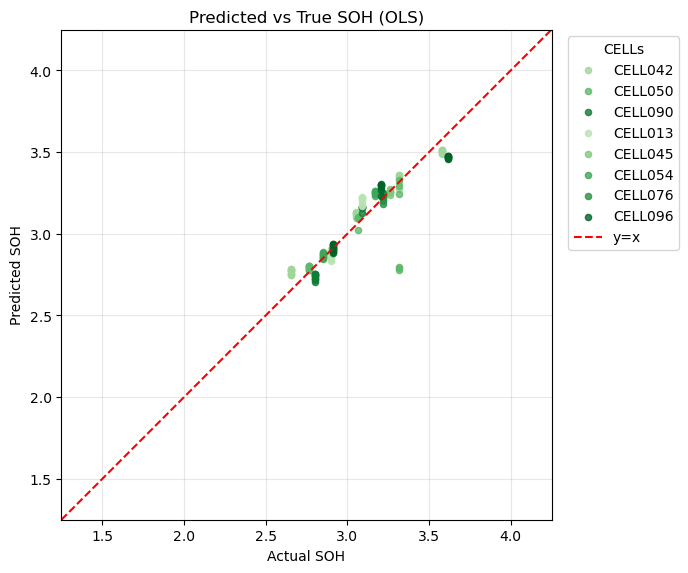

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

# scatter by cell
for cell in df["CELL"].unique():   # <-- adjust column name if it's different
    sub = df[df["CELL"] == cell]
    plt.scatter(
        sub["SOH"], sub["_pred_OLS"],
        alpha=0.8, s=20, label=cell, color=COLOR_MAP[cell]
    )


# 45° reference line
plt.plot([1.25,4.25], [1.25,4.25], "r--",  label="y=x")
plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("Predicted vs True SOH (OLS)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="CELLs")  # put legend outside
plt.grid(alpha=0.3)
plt.axis("equal")
plt.tight_layout()
plt.axis('square')
plt.xlim(1.25, 4.25)
plt.ylim(1.25, 4.25)
plt.show()


Test set visualization:

C:\Users\liuha\AppData\Local\Temp\ipykernel_3624\1254087614.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_cells))


(13725, 28)


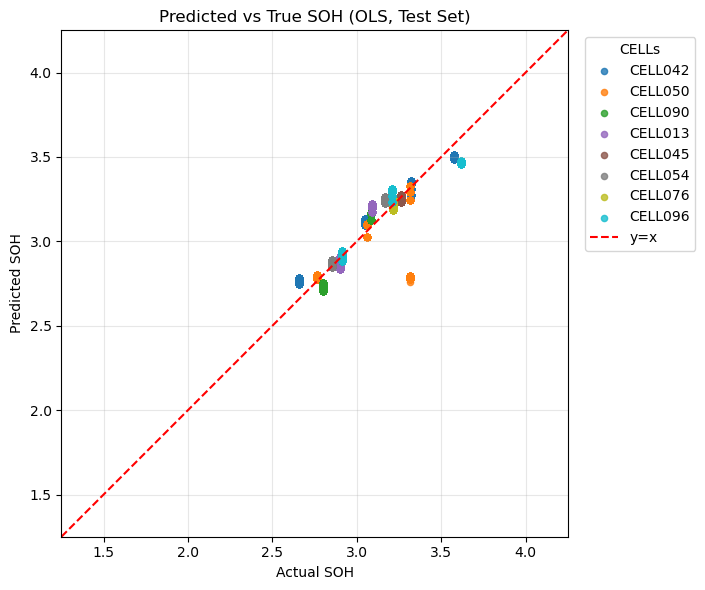

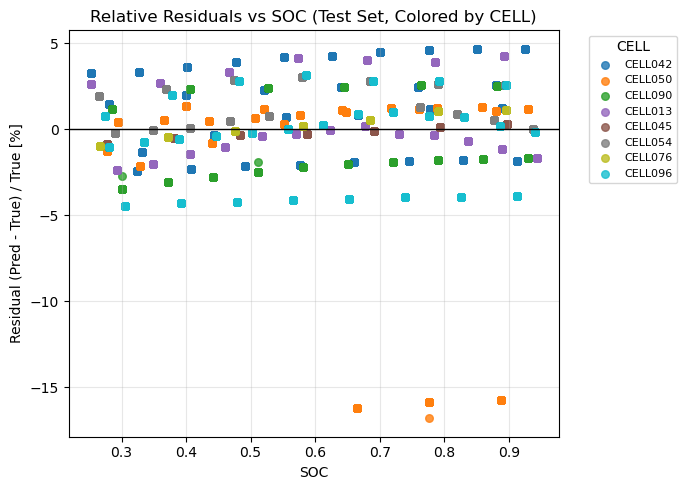

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

# Build color map if not defined
unique_cells = new_df["CELL"].unique()
cmap = plt.cm.get_cmap("tab10", len(unique_cells))
color_map = {cell: cmap(i) for i, cell in enumerate(unique_cells)}

# color_map = COLOR_MAP

# scatter by cell (adjust column name if needed)
print(new_df.shape)
if "CELL" in new_df.columns:
    unique_cells = new_df["CELL"].unique()
    for cell in unique_cells:
        sub = new_df[new_df["CELL"] == cell]
        plt.scatter(
            sub["SOH"], sub["_pred_OLS_mean"],
            alpha=0.8, s=20, label=cell, color=color_map[cell]
        )
else:
    plt.scatter(new_df["SOH"], new_df["_pred_OLS_mean"], alpha=0.8, s=30, color="tab:blue", label="Test data")

# 45° reference line
plt.plot([1.25, 4.25], [1.25, 4.25], "r--", label="y=x")

plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("Predicted vs True SOH (OLS, Test Set)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="CELLs")
plt.grid(alpha=0.3)
plt.axis("equal")
plt.axis("square")
plt.xlim(1.25, 4.25)
plt.ylim(1.25, 4.25)
plt.tight_layout()
plt.show()


if "SOH" in new_df.columns and "_pred_OLS_mean" in new_df.columns:
    new_df["_residual"] = new_df["_pred_OLS_mean"] - new_df["SOH"]
    new_df["rel_residual"] = (new_df["_residual"] / new_df["SOH"]) * 100  # relative error (%)

# ======================================================
# Plot relative residuals vs SOC (colored by CELL)
# ======================================================
if "SOC" in new_df.columns and "CELL" in new_df.columns:
    plt.figure(figsize=(7, 5))

    for cell in unique_cells:
        sub = new_df[new_df["CELL"] == cell]
        plt.scatter(
            sub["SOC"], sub["rel_residual"],
            alpha=0.8, s=30,
            label=cell,
            color=color_map.get(cell, "gray")
        )

    plt.axhline(0, color="black", lw=1)
    plt.xlabel("SOC")
    plt.ylabel("Residual (Pred - True) / True [%]")
    plt.title("Relative Residuals vs SOC (Test Set, Colored by CELL)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, title="CELL")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Columns SOC or CELL not found — skipping residual plot.")


## Experiment 1: Train/Test split on SOC

In [9]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================
# 1) Load data
# =====================================================
df = pd.read_csv("newdf_global_median.csv")

# Use only 25°C cells
df = df[df["Temp"] == 25].copy()
print(f"Full dataset shape: {df.shape}")

# =====================================================
# 2) Standardize continuous predictors (Z-score)
# =====================================================
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

for col in ["R0", "R1", "R2", "R3", "SOC"]:
    df[f"{col}_z"] = zscore(df[col])

# =====================================================
# 3) Train/Test split per SOH — select 3 SOCs randomly
# =====================================================
def select_train_soc_per_soh(group):
    """Randomly select 1 SOC from each of three ranges."""
    ranges = [(0.25, 0.5), (0.5, 0.8), (0.8, 1.0)]
    selected_indices = []
    for low, high in ranges:
        sub = group[(group["SOC"] >= low) & (group["SOC"] < high)]
        if not sub.empty:
            selected_indices.append(sub.sample(1, random_state=42).index[0])
    return selected_indices

# Apply per SOH
train_indices = []
for soh, group in df.groupby("SOH"):
    train_indices.extend(select_train_soc_per_soh(group))

train_df = df.loc[train_indices]
test_df = df.drop(train_indices)

print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

# =====================================================
# 4) Fit OLS model on training subset
# =====================================================
formula = "SOH ~ R0_z + R1_z + R2_z + R3_z + SOC_z"
ols = smf.ols(formula, data=train_df).fit()

print("\n=== OLS Summary (Training) ===")
print(ols.summary())

# =====================================================
# 5) Predict on train & test
# =====================================================
train_df["_pred_OLS"] = ols.predict(train_df)
test_df["_pred_OLS"] = ols.predict(test_df)

# =====================================================
# 6) Evaluate metrics
# =====================================================
def evaluate(y_true, y_pred, label="Set"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"\n=== {label} Performance ===")
    print(f"R²   = {r2:.4f}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"MAPE = {mape:.2f}%")

evaluate(train_df["SOH"], train_df["_pred_OLS"], "Training")
evaluate(test_df["SOH"], test_df["_pred_OLS"], "Testing (Unseen SOCs)")

# =====================================================
# 7) Save results
# =====================================================
train_df["_split"] = "train"
test_df["_split"] = "test"
combined = pd.concat([train_df, test_df], axis=0)
combined.to_csv("df_selected_median_with_ols_experiment1.csv", index=False)

print("\nSaved: df_selected_median_with_ols_experiment1.csv")


Full dataset shape: (202, 16)
Train samples: 54, Test samples: 148

=== OLS Summary (Training) ===
                            OLS Regression Results                            
Dep. Variable:                    SOH   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     33.46
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           1.51e-14
Time:                        17:35:04   Log-Likelihood:                 37.457
No. Observations:                  54   AIC:                            -62.91
Df Residuals:                      48   BIC:                            -50.98
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

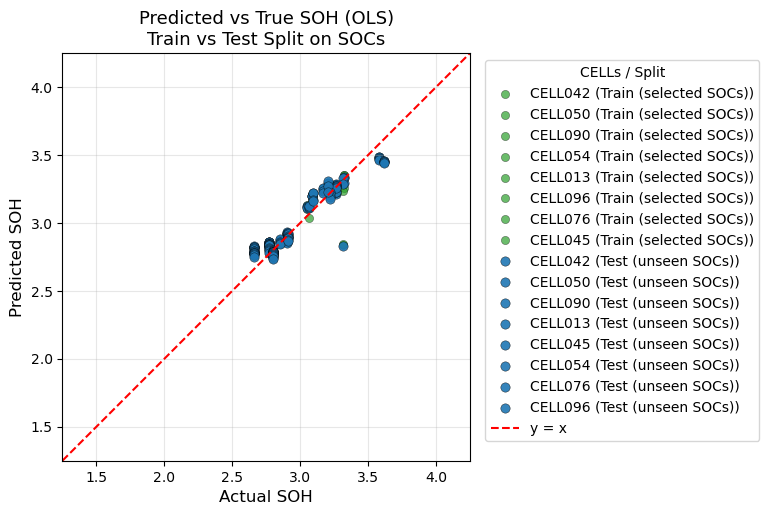

In [10]:
import matplotlib.pyplot as plt

# Define colors for train vs test
split_colors = {"train": "#2ca02c", "test": "#1f77b4"}  # green for train, blue for test
split_labels = {"train": "Train (selected SOCs)", "test": "Test (unseen SOCs)"}

plt.figure(figsize=(7, 6))

# Plot training and testing points by CELL
for split in ["train", "test"]:
    sub_split = combined[combined["_split"] == split]
    for cell in sub_split["CELL"].unique():  # adjust "CELL" column name if different
        sub = sub_split[sub_split["CELL"] == cell]
        plt.scatter(
            sub["SOH"], sub["_pred_OLS"],
            alpha=0.7 if split == "train" else 0.9,
            s=35 if split == "train" else 45,
            label=f"{cell} ({split_labels[split]})",
            color=split_colors[split],
            edgecolor="k",
            linewidth=0.3
        )

# 45° reference line
plt.plot([1.25, 4.25], [1.25, 4.25], "r--", label="y = x")

# Labels and formatting
plt.xlabel("Actual SOH", fontsize=12)
plt.ylabel("Predicted SOH", fontsize=12)
plt.title("Predicted vs True SOH (OLS)\nTrain vs Test Split on SOCs", fontsize=13)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="CELLs / Split")
plt.grid(alpha=0.3)
plt.axis("equal")
plt.axis('square')
plt.xlim(1.25, 4.25)
plt.ylim(1.25, 4.25)
plt.tight_layout()
plt.show()



=== Training Performance ===
R²   = 0.7770
MAE  = 0.0810
RMSE = 0.1209
MAPE = 2.56%

=== Testing (Unseen SOCs) Performance ===
R²   = 0.8869
MAE  = 0.0653
RMSE = 0.0888
MAPE = 2.23%

=== Summary ===
Set                  R²       MAE      RMSE     MAPE(%)
-------------------------------------------------------
Training         0.7770    0.0810    0.1209        2.56
Testing          0.8869    0.0653    0.0888        2.23


C:\Users\liuha\AppData\Local\Temp\ipykernel_171232\687052761.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_cells))


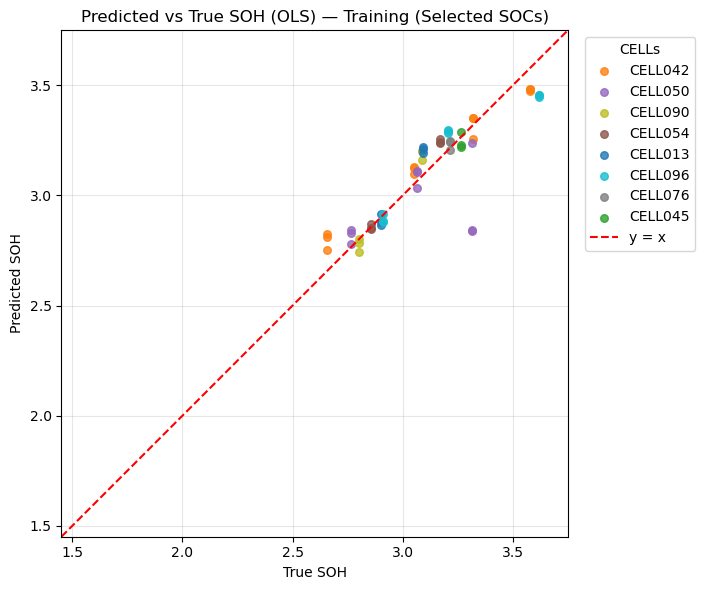

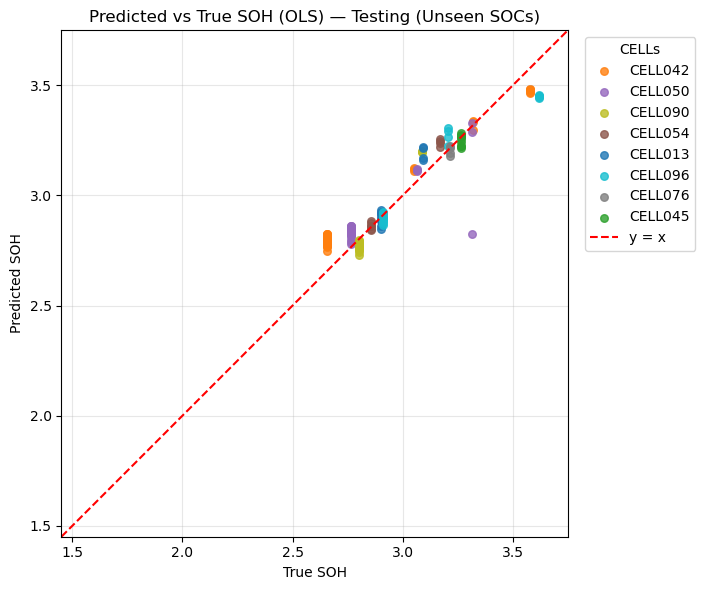

In [21]:
import matplotlib.pyplot as plt

# Build color map if not defined
unique_cells = sorted(combined["CELL"].unique())  # alphabetically sorted
cmap = plt.cm.get_cmap("tab10", len(unique_cells))
color_map = {cell: cmap(i) for i, cell in enumerate(unique_cells)}

# =====================================================
# Define evaluation helper
# =====================================================
def evaluate(y_true, y_pred, label="Set"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"\n=== {label} Performance ===")
    print(f"R²   = {r2:.4f}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"MAPE = {mape:.2f}%")
    return r2, mae, rmse, mape


# =====================================================
# Compute metrics for train and test
# =====================================================
train_df = combined[combined["_split"] == "train"]
test_df  = combined[combined["_split"] == "test"]

r2_train, mae_train, rmse_train, mape_train = evaluate(train_df["SOH"], train_df["_pred_OLS"], "Training")
r2_test, mae_test, rmse_test, mape_test     = evaluate(test_df["SOH"], test_df["_pred_OLS"], "Testing (Unseen SOCs)")


# =====================================================
# Print summary neatly
# =====================================================
print("\n=== Summary ===")
print(f"{'Set':<15}{'R²':>8}{'MAE':>10}{'RMSE':>10}{'MAPE(%)':>12}")
print("-" * 55)
print(f"{'Training':<15}{r2_train:>8.4f}{mae_train:>10.4f}{rmse_train:>10.4f}{mape_train:>12.2f}")
print(f"{'Testing':<15}{r2_test:>8.4f}{mae_test:>10.4f}{rmse_test:>10.4f}{mape_test:>12.2f}")


# --- TRAINING SET PLOT ---
plt.figure(figsize=(7, 6))
for cell in combined["CELL"].unique():
    sub = combined[(combined["CELL"] == cell) & (combined["_split"] == "train")]
    if len(sub) == 0:
        continue
    plt.scatter(
        sub["SOH"], sub["_pred_OLS"],
        color=color_map[cell],
        alpha=0.8, s=30, label=cell
    )

plt.plot([1.45, 3.75], [1.45, 3.75], "r--", label="y = x")
plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title("Predicted vs True SOH (OLS) — Training (Selected SOCs)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="CELLs")
plt.grid(alpha=0.3)
plt.axis("equal")
plt.axis("square")
plt.xlim(1.45, 3.75)
plt.ylim(1.45, 3.75)
plt.tight_layout()
plt.show()

# --- TEST SET PLOT ---
plt.figure(figsize=(7, 6))
for cell in combined["CELL"].unique():
    sub = combined[(combined["CELL"] == cell) & (combined["_split"] == "test")]
    if len(sub) == 0:
        continue
    plt.scatter(
        sub["SOH"], sub["_pred_OLS"],
        color=color_map[cell],
        alpha=0.8, s=30, label=cell
    )

plt.plot([1.45, 3.75], [1.45, 3.75], "r--", label="y = x")
plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title("Predicted vs True SOH (OLS) — Testing (Unseen SOCs)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="CELLs")
plt.grid(alpha=0.3)
plt.axis("equal")
plt.axis("square")
plt.xlim(1.45, 3.75)
plt.ylim(1.45, 3.75)
plt.tight_layout()
plt.show()


## Experiment 2: Train/Test split on Cells (Leave-one-out Cross Validation) [Toggle TRUE/FALSE to do Experiment 3]

Filtered dataset shape: (202, 16)

Leaving out CELL: CELL013
Reduced training samples: 48 (26.4% of original)
Train shape: (48, 16), Test shape: (20, 16)

=== Training Performance ===
R²   = 0.7830
MAE  = 0.0843
RMSE = 0.1242
MAPE = 2.67%

=== Testing (CELL=CELL013) Performance ===
R²   = 0.0682
MAE  = 0.0720
RMSE = 0.0869
MAPE = 2.38%


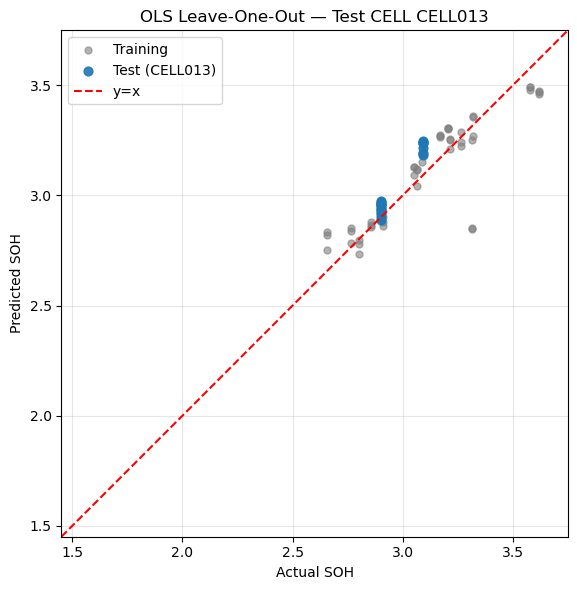


Leaving out CELL: CELL042
Reduced training samples: 42 (26.9% of original)
Train shape: (42, 16), Test shape: (46, 16)

=== Training Performance ===
R²   = 0.6941
MAE  = 0.0830
RMSE = 0.1242
MAPE = 2.60%

=== Testing (CELL=CELL042) Performance ===
R²   = 0.8256
MAE  = 0.1406
RMSE = 0.1539
MAPE = 4.97%


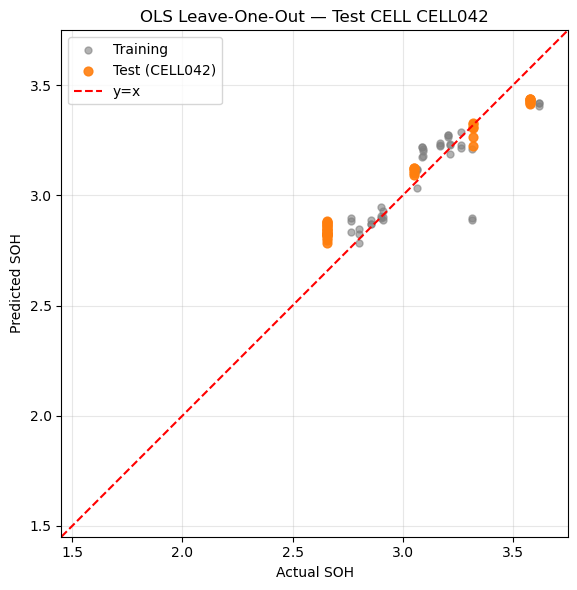


Leaving out CELL: CELL045
Reduced training samples: 51 (27.0% of original)
Train shape: (51, 16), Test shape: (13, 16)

=== Training Performance ===
R²   = 0.7729
MAE  = 0.0837
RMSE = 0.1241
MAPE = 2.65%

=== Testing (CELL=CELL045) Performance ===
R²   = 0.0000
MAE  = 0.0239
RMSE = 0.0296
MAPE = 0.73%


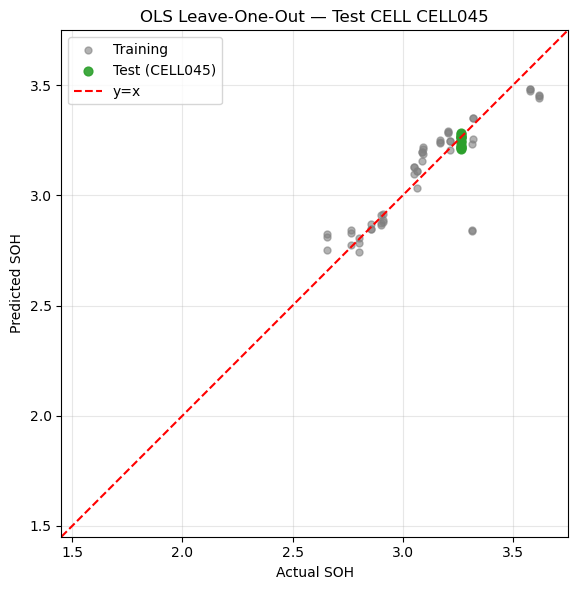


Leaving out CELL: CELL050
Reduced training samples: 45 (27.6% of original)
Train shape: (45, 16), Test shape: (39, 16)

=== Training Performance ===
R²   = 0.9348
MAE  = 0.0567
RMSE = 0.0665
MAPE = 1.83%

=== Testing (CELL=CELL050) Performance ===
R²   = 0.1840
MAE  = 0.1097
RMSE = 0.1875
MAPE = 3.65%


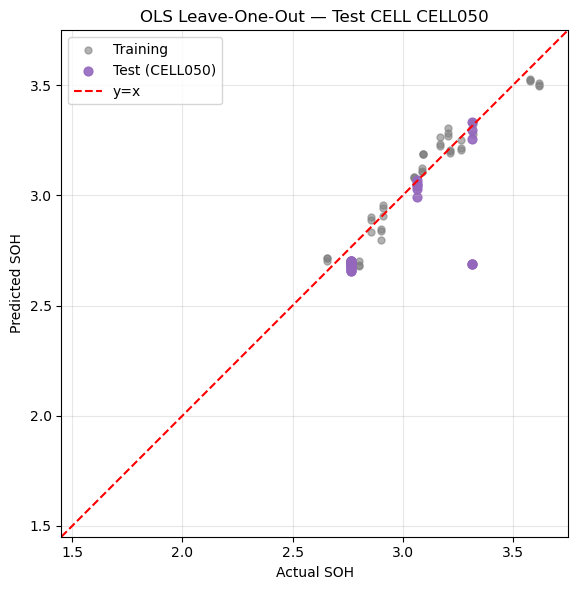


Leaving out CELL: CELL054
Reduced training samples: 48 (25.8% of original)
Train shape: (48, 16), Test shape: (16, 16)

=== Training Performance ===
R²   = 0.7698
MAE  = 0.0851
RMSE = 0.1265
MAPE = 2.69%

=== Testing (CELL=CELL054) Performance ===
R²   = 0.8472
MAE  = 0.0474
RMSE = 0.0609
MAPE = 1.53%


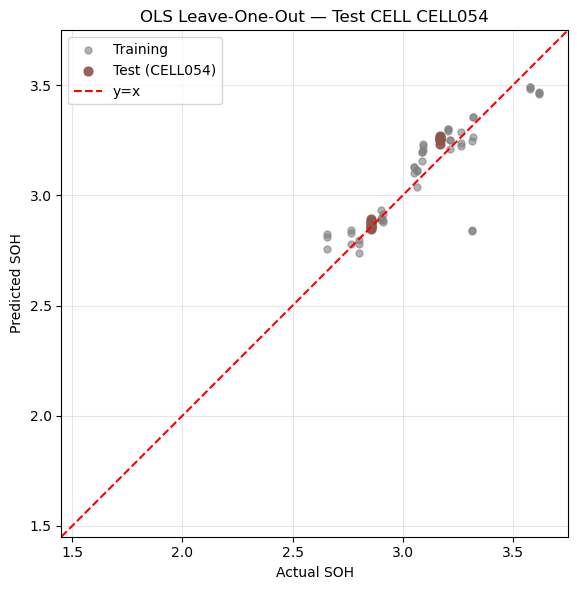


Leaving out CELL: CELL076
Reduced training samples: 51 (26.2% of original)
Train shape: (51, 16), Test shape: (7, 16)

=== Training Performance ===
R²   = 0.7751
MAE  = 0.0849
RMSE = 0.1243
MAPE = 2.68%

=== Testing (CELL=CELL076) Performance ===
R²   = 0.0000
MAE  = 0.0212
RMSE = 0.0247
MAPE = 0.66%


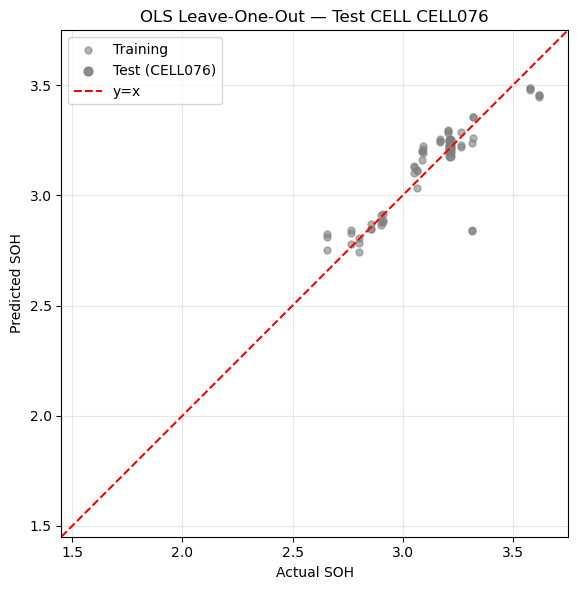


Leaving out CELL: CELL090
Reduced training samples: 48 (28.4% of original)
Train shape: (48, 16), Test shape: (33, 16)

=== Training Performance ===
R²   = 0.7769
MAE  = 0.0873
RMSE = 0.1229
MAPE = 2.78%

=== Testing (CELL=CELL090) Performance ===
R²   = 0.3114
MAE  = 0.0581
RMSE = 0.0914
MAPE = 1.95%


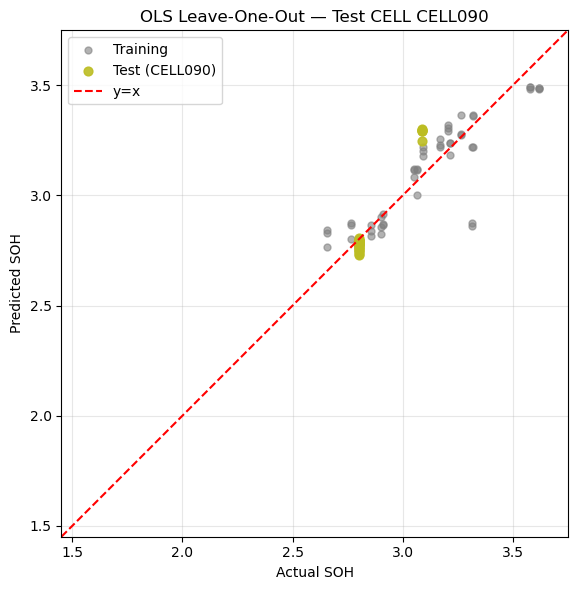


Leaving out CELL: CELL096
Reduced training samples: 45 (25.9% of original)
Train shape: (45, 16), Test shape: (28, 16)

=== Training Performance ===
R²   = 0.7427
MAE  = 0.0819
RMSE = 0.1213
MAPE = 2.63%

=== Testing (CELL=CELL096) Performance ===
R²   = 0.8002
MAE  = 0.1075
RMSE = 0.1329
MAPE = 3.22%


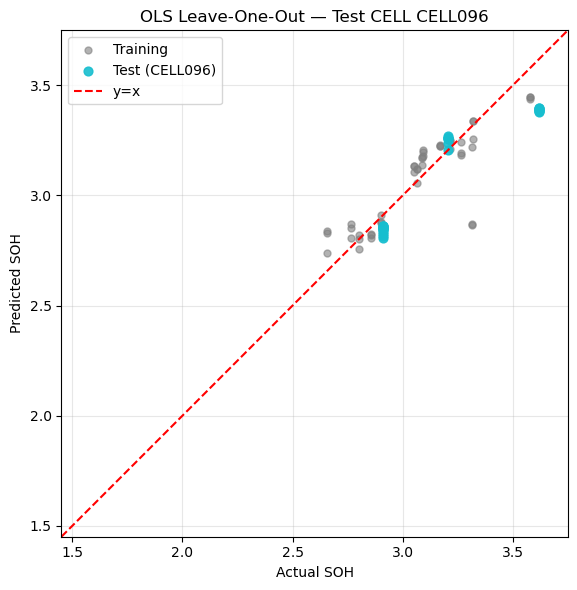


Saved metrics to ols_leave_one_cell_out_metrics.csv

=== Overall Summary ===
      Cell   R2_test  MAE_test  RMSE_test  MAPE_test
0  CELL013  0.068238  0.071964   0.086920   2.382613
1  CELL042  0.825552  0.140627   0.153915   4.973603
2  CELL045  0.000000  0.023935   0.029576   0.733538
3  CELL050  0.184004  0.109672   0.187455   3.646322
4  CELL054  0.847249  0.047442   0.060926   1.527416
5  CELL076  0.000000  0.021167   0.024703   0.658281
6  CELL090  0.311365  0.058126   0.091423   1.953839
7  CELL096  0.800170  0.107490   0.132875   3.221717


In [25]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib as mpl

# =====================================================
# 1) Load and filter data
# =====================================================
df = pd.read_csv("newdf_global_median.csv")
df = df[df["Temp"] == 25].copy()
print(f"Filtered dataset shape: {df.shape}")

# =====================================================
# 2) Define helper functions
# =====================================================
def zscore_with_stats(series, mean, std):
    return (series - mean) / std

def evaluate(y_true, y_pred, label="Set"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"\n=== {label} Performance ===")
    print(f"R²   = {r2:.4f}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"MAPE = {mape:.2f}%")
    return r2, mae, rmse, mape

# =====================================================
# 2.5) Helper for Experiment 3 – Reduced SOC sampling
# =====================================================
def reduce_training_samples(df_train, cell_col="CELL", soc_col="SOC", soh_col="SOH", random_state=42):
    """
    For each CELL and each SOH, select 3 SOC points (one per range)
    and include ALL rows corresponding to those SOCs (e.g., all trials).
    """
    np.random.seed(random_state)
    soc_ranges = [(0.25, 0.5), (0.5, 0.8), (0.8, 1.0)]
    selected_soc_values = []

    for cell, cell_group in df_train.groupby(cell_col):
        for soh, soh_group in cell_group.groupby(soh_col):
            for (low, high) in soc_ranges:
                subset = soh_group[(soh_group[soc_col] >= low) & (soh_group[soc_col] < high)]
                if not subset.empty:
                    # randomly select one SOC value
                    soc_value = subset[soc_col].sample(1, random_state=random_state).iloc[0]
                    selected_soc_values.append((cell, soh, soc_value))

    # Include all rows for those SOC values (i.e., all trials)
    selected_rows = []
    for (cell, soh, soc_value) in selected_soc_values:
        mask = (
            (df_train[cell_col] == cell)
            & (df_train[soh_col] == soh)
            & (np.isclose(df_train[soc_col], soc_value, atol=1e-6))
        )
        selected_rows.append(df_train[mask])

    reduced_df = pd.concat(selected_rows, ignore_index=True)

    print(f"Reduced training samples: {len(reduced_df)} "
          f"({len(reduced_df) / len(df_train) * 100:.1f}% of original)")
    return reduced_df


# =====================================================
# 3) Define the cells to iterate
# =====================================================
cells = sorted(df["CELL"].unique())  # or your custom list

# Color map for consistent plotting
cmap = mpl.colormaps.get_cmap("tab10").resampled(len(cells))
COLOR_MAP = {cell: cmap(i) for i, cell in enumerate(cells)}

# To store results
results = []

# =====================================================
# 4) Leave-One-Cell-Out CV
# =====================================================
for test_cell in cells:
    print(f"\n===============================")
    print(f"Leaving out CELL: {test_cell}")
    print(f"===============================")

    train_df = df[df["CELL"] != test_cell].copy()
    # =====================================================
    # (Optional) Apply SOC reduction — Experiment 3 condition
    # =====================================================
    REDUCED_TRAINING = True  # NOTE: toggle ON for Experiment 3
    if REDUCED_TRAINING:
        train_df = reduce_training_samples(train_df)
    test_df = df[df["CELL"] == test_cell].copy()
    print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

    # Compute training means/stds
    train_means = {col: train_df[col].mean() for col in ["R0", "R1", "R2", "R3", "SOC"]}
    train_stds  = {col: train_df[col].std(ddof=0) for col in ["R0", "R1", "R2", "R3", "SOC"]}

    # Standardize both train/test using training stats
    for col in ["R0", "R1", "R2", "R3", "SOC"]:
        train_df[f"{col}_z"] = zscore_with_stats(train_df[col], train_means[col], train_stds[col])
        test_df[f"{col}_z"]  = zscore_with_stats(test_df[col], train_means[col], train_stds[col])

    # Fit OLS model
    formula = "SOH ~ R0_z + R1_z + R2_z + R3_z + SOC_z"
    ols = smf.ols(formula, data=train_df).fit()

    # Predict
    train_df["_pred_OLS"] = ols.predict(train_df)
    test_df["_pred_OLS"]  = ols.predict(test_df)

    # Evaluate
    train_metrics = evaluate(train_df["SOH"], train_df["_pred_OLS"], "Training")
    test_metrics  = evaluate(test_df["SOH"], test_df["_pred_OLS"], f"Testing (CELL={test_cell})")

    # Store metrics
    results.append({
        "Cell": test_cell,
        "R2_train": train_metrics[0],
        "MAE_train": train_metrics[1],
        "RMSE_train": train_metrics[2],
        "MAPE_train": train_metrics[3],
        "R2_test": test_metrics[0],
        "MAE_test": test_metrics[1],
        "RMSE_test": test_metrics[2],
        "MAPE_test": test_metrics[3],
    })

    # =====================================================
    # 5) Plot Train/Test for this CELL
    # =====================================================
    plt.figure(figsize=(7,6))
    plt.scatter(train_df["SOH"], train_df["_pred_OLS"], alpha=0.6, s=25, color="gray", label="Training")
    plt.scatter(test_df["SOH"], test_df["_pred_OLS"], alpha=0.9, s=40, color=COLOR_MAP[test_cell], label=f"Test ({test_cell})")
    plt.plot([1.45, 3.75], [1.45, 3.75], "r--", label="y=x")
    plt.xlabel("Actual SOH")
    plt.ylabel("Predicted SOH")
    plt.title(f"OLS Leave-One-Out — Test CELL {test_cell}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.axis("square")
    plt.xlim(1.45, 3.75)
    plt.ylim(1.45, 3.75)
    plt.tight_layout()
    plt.show()

# =====================================================
# 6) Save and summarize
# =====================================================
results_df = pd.DataFrame(results)
exp_tag = "_Exp3_reducedSOC" if REDUCED_TRAINING else ""
results_df.to_csv(f"ols_leave_one_cell_out_metrics{exp_tag}.csv", index=False)
print("\nSaved metrics to ols_leave_one_cell_out_metrics.csv")

print("\n=== Overall Summary ===")
print(results_df[["Cell", "R2_test", "MAE_test", "RMSE_test", "MAPE_test"]])


## Experiment 4: Continual Learning


OLS Continual Learning Stage 1/7
Training on: ['CELL090']
Testing on unseen cells: ['CELL050', 'CELL042', 'CELL076', 'CELL045', 'CELL096', 'CELL013', 'CELL054']
Train shape: (33, 15), Test shape: (169, 15)
Validation: MAPE=0.11% | Test: MAPE=5.96%

OLS Continual Learning Stage 2/7
Training on: ['CELL090', 'CELL050']
Testing on unseen cells: ['CELL042', 'CELL076', 'CELL045', 'CELL096', 'CELL013', 'CELL054']
Train shape: (72, 15), Test shape: (130, 15)
Validation: MAPE=1.99% | Test: MAPE=4.85%

OLS Continual Learning Stage 3/7
Training on: ['CELL090', 'CELL050', 'CELL042']
Testing on unseen cells: ['CELL076', 'CELL045', 'CELL096', 'CELL013', 'CELL054']
Train shape: (118, 15), Test shape: (84, 15)
Validation: MAPE=1.50% | Test: MAPE=3.28%

OLS Continual Learning Stage 4/7
Training on: ['CELL090', 'CELL050', 'CELL042', 'CELL076']
Testing on unseen cells: ['CELL045', 'CELL096', 'CELL013', 'CELL054']
Train shape: (125, 15), Test shape: (77, 15)
Validation: MAPE=2.14% | Test: MAPE=3.24%

OLS

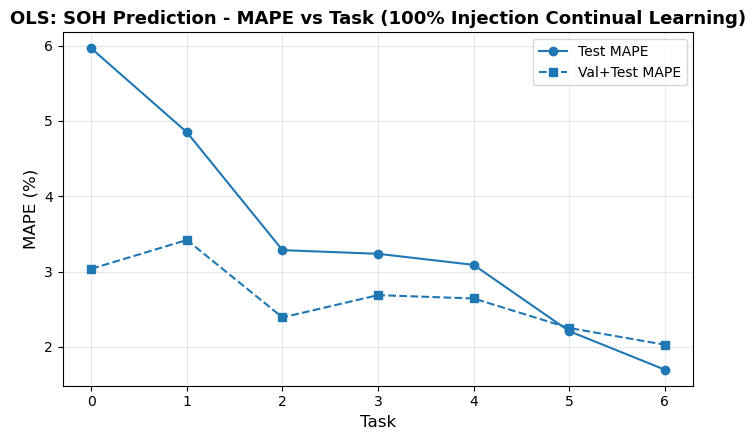

In [29]:
import os
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===============================================================
# OLS Regression - Continual Learning (25°C cells)
# ===============================================================
def main_OLS_CL():
    # -------------------------------
    # Load metadata and dataset
    # -------------------------------
    battery_json_file = "../EVC_EIS_Data/original_data/Battery_Info_DRT.json"
    with open(battery_json_file, "r") as f:
        battery_metadata = json.load(f)

    df_all = pd.read_csv("newdf_global_median.csv", index_col=0)
    FEATURES = ["R0", "R1", "R2", "R3", "SOC"]
    TARGET = "SOH"
    df_all = df_all.dropna(subset=["CELL", "SOH", "SOC", "Temp"] + FEATURES).reset_index(drop=True)

    # Cells order for 25°C continual learning experiment
    cells_order = ["CELL090","CELL050","CELL042","CELL076","CELL045","CELL096","CELL013","CELL054"]
    base_cell = cells_order[0]
    all_metrics = []

    # -------------------------------
    # Continual Learning Loop
    # -------------------------------
    for task_idx in range(1, len(cells_order)):
        train_cells = cells_order[:task_idx]
        unseen_cells = cells_order[task_idx:]

        print(f"\n============================")
        print(f"OLS Continual Learning Stage {task_idx}/{len(cells_order)-1}")
        print(f"Training on: {train_cells}")
        print(f"Testing on unseen cells: {unseen_cells}")
        print(f"============================")

        df_train = df_all[df_all["CELL"].isin(train_cells)].copy()
        df_test = df_all[df_all["CELL"].isin(unseen_cells)].copy()
        print(f"Train shape: {df_train.shape}, Test shape: {df_test.shape}")

        X = df_train[FEATURES].values
        y = df_train[TARGET].values
        X_test = df_test[FEATURES].values
        y_test = df_test[TARGET].values

        # Split train/val
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

        # Standardize
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        X_test = scaler.transform(X_test)

        # Fit OLS
        model = LinearRegression()
        model.fit(X_train, y_train)

        # Validation evaluation
        y_val_pred = model.predict(X_val)
        val_mae = mean_absolute_error(y_val, y_val_pred)
        val_rmse = math.sqrt(mean_squared_error(y_val, y_val_pred))
        val_mape = np.mean(np.abs((y_val - y_val_pred) / np.clip(np.abs(y_val), 1e-6, None))) * 100
        val_r2 = r2_score(y_val, y_val_pred)

        # Test evaluation
        y_test_pred = model.predict(X_test)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_rmse = math.sqrt(mean_squared_error(y_test, y_test_pred))
        test_mape = np.mean(np.abs((y_test - y_test_pred) / np.clip(np.abs(y_test), 1e-6, None))) * 100
        test_r2 = r2_score(y_test, y_test_pred)

        print(f"Validation: MAPE={val_mape:.2f}% | Test: MAPE={test_mape:.2f}%")

        all_metrics.append({
            "Task": task_idx,
            "Train_Cells": ",".join(train_cells),
            "Unseen_Cells": ",".join(unseen_cells),
            "Val_MAPE": val_mape,
            "Test_MAPE": test_mape,
            "Val_MAE": val_mae,
            "Test_MAE": test_mae,
            "Val_R2": val_r2,
            "Test_R2": test_r2
        })

    # -------------------------------
    # Save Summary
    # -------------------------------
    results_df = pd.DataFrame(all_metrics)
    results_df.to_csv("OLS_Experiment4_ContinualLearning_25C.csv", index=False)
    print("\n✅ OLS Experiment 4 completed. Metrics saved to 'OLS_Experiment4_ContinualLearning_25C.csv'")

    # -------------------------------
    # Summary table
    # -------------------------------
    summary_rows = []
    for i, row in enumerate(all_metrics):
        task = i
        injected = "– (only train on CELL090)" if task == 0 else ", ".join(cells_order[1:task+1])
        summary_rows.append({
            "Task": task,
            "Injected Cells": injected,
            "Test MAPE (%)": row["Test_MAPE"]
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv("OLS_Experiment4_ContinualLearning_25C_Summary.csv", index=False)

    print("\n==================== Summary: OLS Continual Learning ====================")
    print(summary_df.to_string(index=False, formatters={"Test MAPE (%)": "{:.2f}".format}))
    print("==========================================================================\n")

    # -------------------------------
    # Plot MAPE vs Task
    # -------------------------------
    val_mapes = [m["Val_MAPE"] for m in all_metrics]
    test_mapes = [m["Test_MAPE"] for m in all_metrics]
    combined_mapes = [(v + t)/2 for v, t in zip(val_mapes, test_mapes)]

    plt.figure(figsize=(7, 4.5))
    plt.plot(summary_df["Task"], test_mapes, marker='o', linestyle='-', color='tab:blue', label="Test MAPE")
    plt.plot(summary_df["Task"], combined_mapes, marker='s', linestyle='--', color='tab:blue', label="Val+Test MAPE")
    plt.xlabel("Task", fontsize=12)
    plt.ylabel("MAPE (%)", fontsize=12)
    plt.title("OLS: SOH Prediction - MAPE vs Task (100% Injection Continual Learning)", fontsize=13, weight='bold')
    plt.grid(alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("OLS_Experiment4_MAPE_vs_Task.png", dpi=300)
    plt.show()


if __name__ == "__main__":
    main_OLS_CL()


# R SOH Temp

In [20]:
def R_SOH_Temp_plot(R='R1'):
    df = pd.read_csv('df_global_median.csv')

    # Plot
    plt.figure(figsize=(8, 6))

    for cell, color in COLOR_MAP.items():
        cell_data = df[df['CELL'] == cell]
        if not cell_data.empty:
            plt.scatter(cell_data[R], cell_data['SOH'], label=cell, color=color, alpha=0.7)


    plt.xlabel(f'{R}')
    plt.ylabel('SOH')
    plt.title(f'SOH vs {R} by CELL')
    plt.legend(title='CELL')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot Average SOC

    # For each (CELL, SOH), take:
    # - mean of R
    agg_df = (
        df.groupby(['CELL', 'SOH'], as_index=False)
        .agg({R: 'mean'})
    )

    # Plot
    plt.figure(figsize=(8, 6))

    for cell, color in COLOR_MAP.items():
        cell_data = agg_df[agg_df['CELL'] == cell].sort_values(by='SOH')
        if not cell_data.empty:
            plt.plot(cell_data[R], cell_data['SOH'], color=color, label=cell,
                    linewidth=2, marker='o', markersize=6, alpha=0.8)

    plt.xlabel(f'{R} (average per SOH)')
    plt.ylabel('SOH')
    plt.title(f'SOH vs {R} by CELL ({R} averaged per SOH)')
    plt.legend(title='CELL')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


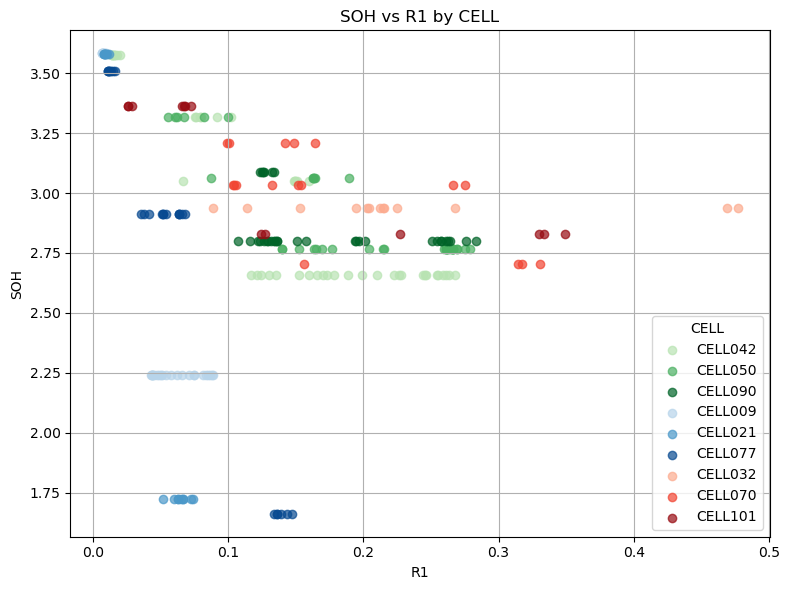

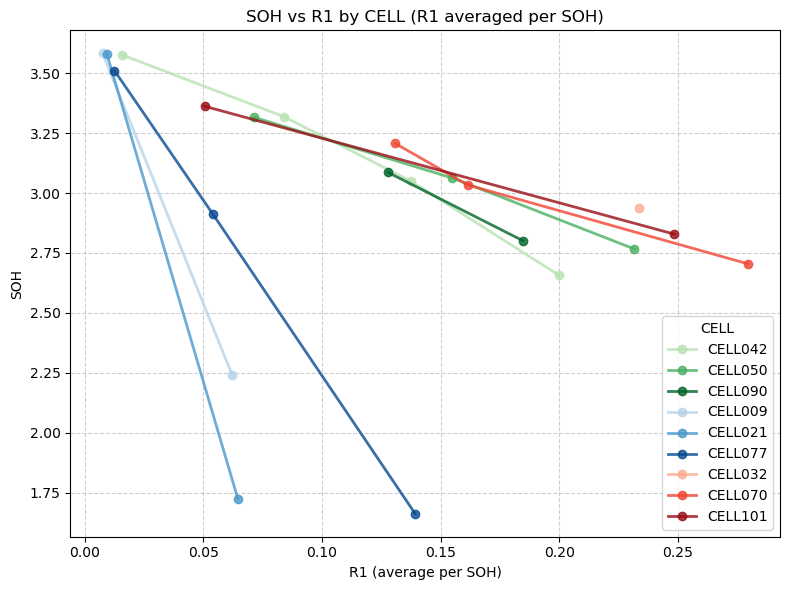

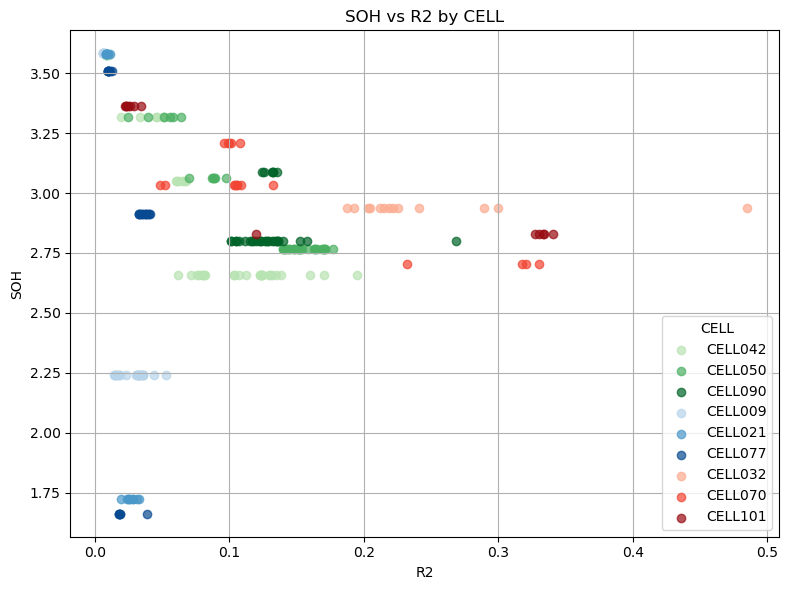

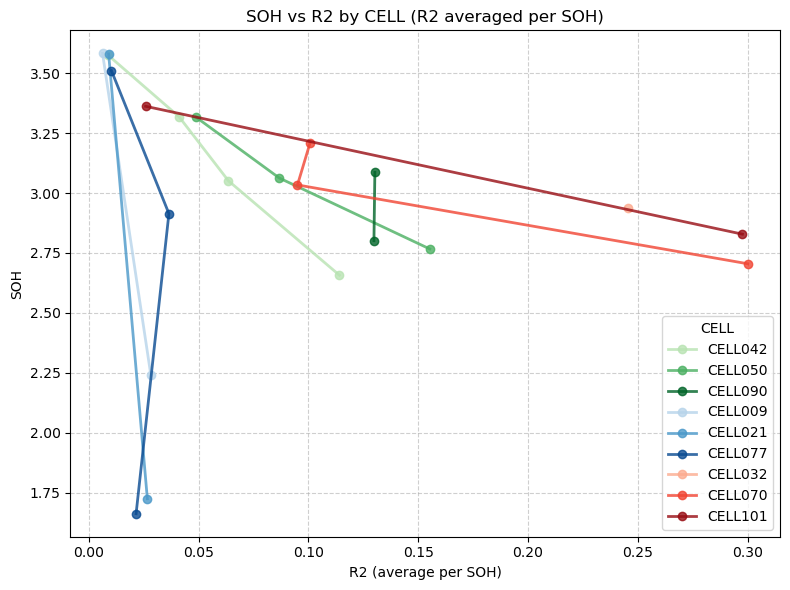

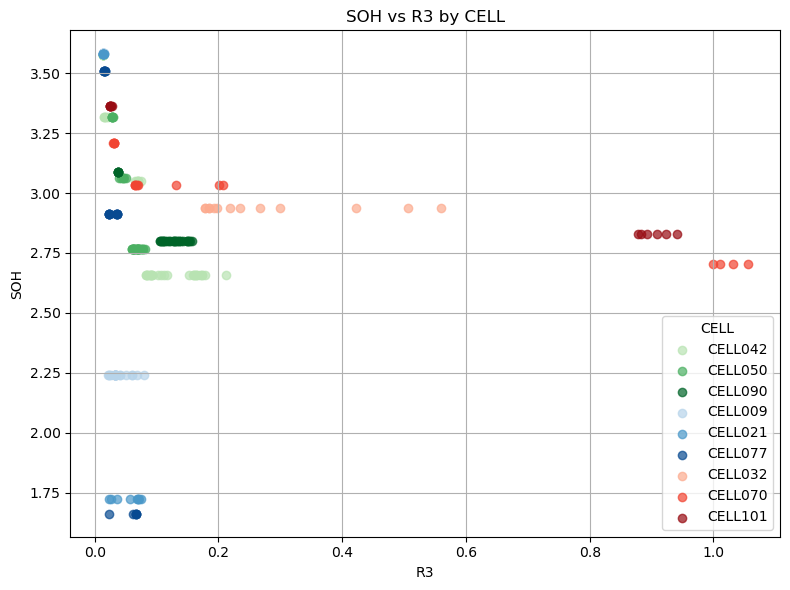

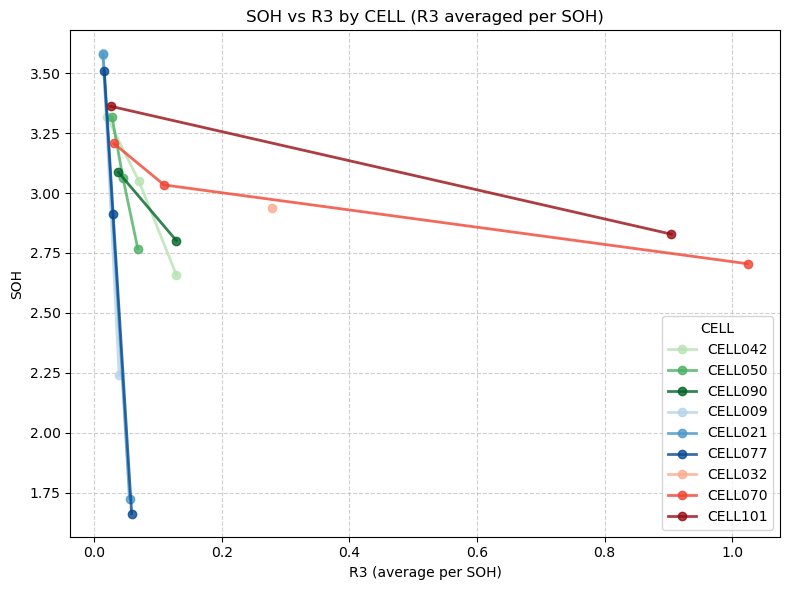

In [22]:
R_SOH_Temp_plot("R1")
R_SOH_Temp_plot("R2")
R_SOH_Temp_plot("R3")



# Model Exp

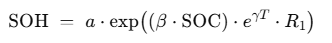

Fitted parameters: a=3.283, beta=-8.171, gamma=-0.07369


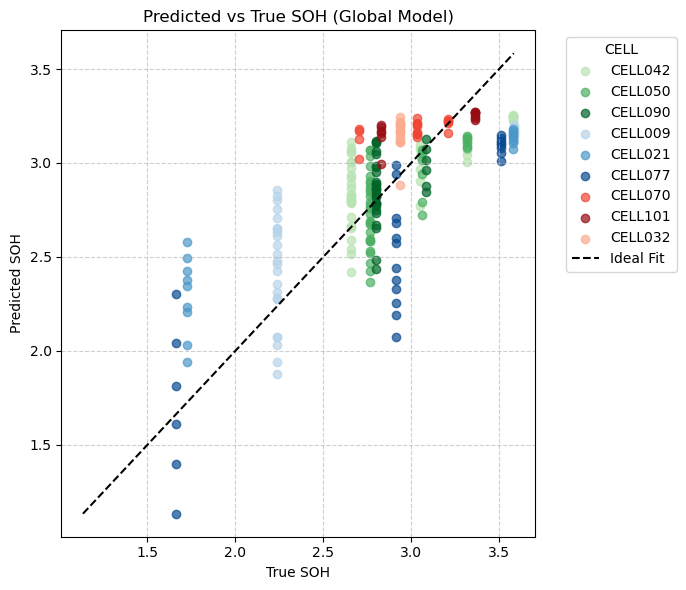

R² = 0.5821, RMSE = 0.3054


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------
# Load data and define model
# ----------------------------
df = pd.read_csv("df_global_median.csv")
df = df[['CELL', 'Temp', 'R1', 'SOH', 'SOC']].dropna()

def soh_model(xdata, a, beta, gamma):
    R1, T, SOC = xdata
    return a * np.exp((beta * SOC) * np.exp(gamma * T) * R1)

R1_all  = df['R1'].to_numpy(float)
T_all   = df['Temp'].to_numpy(float)
SOC_all = df['SOC'].to_numpy(float)
y_true  = df['SOH'].to_numpy(float)

# ----------------------------
# Fit a single global model
# ----------------------------
p0 = [max(np.median(y_true), 1e-3), 1e-3, 0.0]
bounds = ([1e-12, -np.inf, -np.inf], [np.inf, np.inf, np.inf])

popt, _ = curve_fit(
    soh_model, 
    xdata=(R1_all, T_all, SOC_all), 
    ydata=y_true, 
    p0=p0, 
    bounds=bounds,
    maxfev=30000
)
a_hat, beta_hat, gamma_hat = popt
print(f"Fitted parameters: a={a_hat:.4g}, beta={beta_hat:.4g}, gamma={gamma_hat:.4g}")

# ----------------------------
# Predict SOH using fitted model
# ----------------------------
y_pred = soh_model((R1_all, T_all, SOC_all), a_hat, beta_hat, gamma_hat)

# ----------------------------
# Plot predicted vs true SOH
# ----------------------------
plt.figure(figsize=(7, 6))
cells = df['CELL'].unique()


for cell in cells:
    mask = df['CELL'] == cell
    plt.scatter(y_true[mask], y_pred[mask], color=COLOR_MAP[cell], alpha=0.7, label=cell)

# Add 1:1 reference line
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'k--', lw=1.5, label='Ideal Fit')

plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title("Predicted vs True SOH (Global Model)")
plt.legend(title='CELL', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: compute fit metrics
# ----------------------------
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
print(f"R² = {r2:.4f}, RMSE = {rmse:.4f}")


(235,)
Fitted parameters: a=3.401, beta_1=-1.308, beta_2=0.1851, beta_3=-5.209, gamma=-0.06755


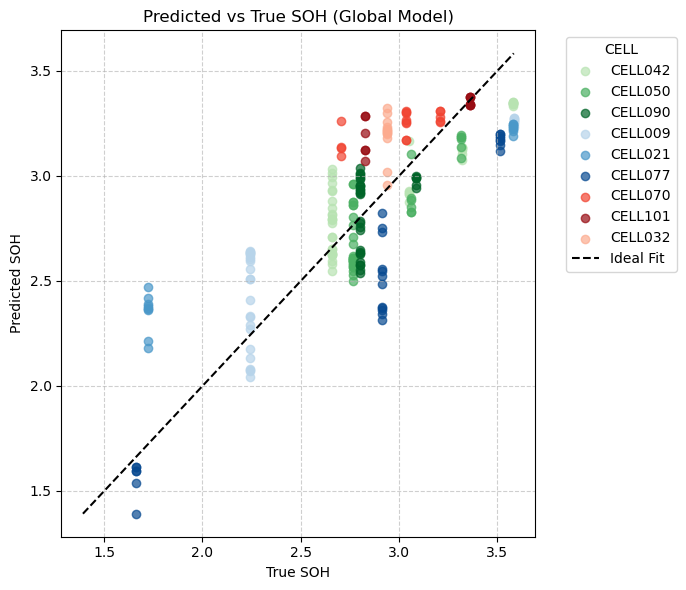

R² = 0.6731, RMSE = 0.2701


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------
# Load data and define model
# ----------------------------
df = pd.read_csv("df_global_median.csv")
df = df[['CELL', 'Temp', 'R1', 'SOH', 'SOC']].dropna()

def soh_model(xdata, a, beta1, beta2, beta3, gamma):
    R1, T, SOC = xdata
    return a * np.exp((beta1 * SOC*SOC + beta2 * SOC + beta3) * np.exp(gamma * T) * R1)

R1_all  = df['R1'].to_numpy(float)
T_all   = df['Temp'].to_numpy(float)
SOC_all = df['SOC'].to_numpy(float)
y_true  = df['SOH'].to_numpy(float)
print(R1_all.shape)

# ----------------------------
# Fit a single global model
# ----------------------------
p0 = [max(np.median(y_true), 1), 1, 1, 1, 0.0]
bounds = ([1e-12, -np.inf, -np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf, np.inf])

popt, _ = curve_fit(
    soh_model, 
    xdata=(R1_all, T_all, SOC_all), 
    ydata=y_true, 
    p0=p0, 
    bounds=bounds,
    maxfev=30000
)
a_hat, beta1_hat, beta2_hat, beta3_hat, gamma_hat = popt
print(f"Fitted parameters: a={a_hat:.4g}, beta_1={beta1_hat:.4g}, beta_2={beta2_hat:.4g}, beta_3={beta3_hat:.4g}, gamma={gamma_hat:.4g}")

# ----------------------------
# Predict SOH using fitted model
# ----------------------------
y_pred = soh_model((R1_all, T_all, SOC_all), a_hat, beta1_hat, beta2_hat, beta3_hat,gamma_hat)

# ----------------------------
# Plot predicted vs true SOH
# ----------------------------
plt.figure(figsize=(7, 6))
cells = df['CELL'].unique()


for cell in cells:
    mask = df['CELL'] == cell
    plt.scatter(y_true[mask], y_pred[mask], color=COLOR_MAP[cell], alpha=0.7, label=cell)

# Add 1:1 reference line
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'k--', lw=1.5, label='Ideal Fit')

plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title("Predicted vs True SOH (Global Model)")
plt.legend(title='CELL', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: compute fit metrics
# ----------------------------
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
print(f"R² = {r2:.4f}, RMSE = {rmse:.4f}")


Fitted parameters: a=3.435, beta_1=0.1445, beta_2=-0.2621, beta_3=-0.2396, gamma=0.05015


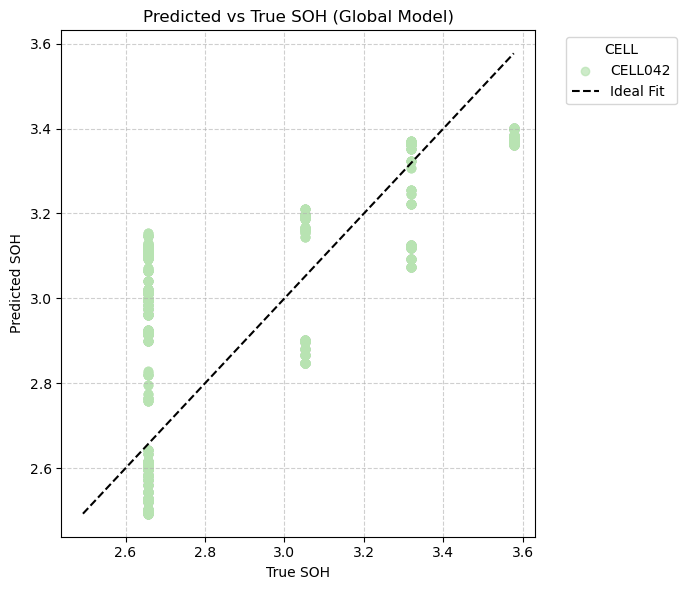

R² = 0.6230, RMSE = 0.2294


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------
# Load data and define model
# ----------------------------
df = pd.read_csv("df_global_all.csv")
df = df[['CELL', 'Temp', 'R1', 'SOH', 'SOC']].dropna()
df = df[0:2000]

def soh_model(xdata, a, beta1, beta2, beta3, gamma):
    R1, T, SOC = xdata
    return a * np.exp((beta1 * SOC*SOC + beta2 * SOC + beta3) * np.exp(gamma * T) * R1)

R1_all  = df['R1'].to_numpy(float)
T_all   = df['Temp'].to_numpy(float)
SOC_all = df['SOC'].to_numpy(float)
y_true  = df['SOH'].to_numpy(float)

# ----------------------------
# Fit a single global model
# ----------------------------
p0 = [max(np.median(y_true), 1), 1, 1, 1, 0.0]
bounds = ([1e-12, -np.inf, -np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf, np.inf])

popt, _ = curve_fit(
    soh_model, 
    xdata=(R1_all, T_all, SOC_all), 
    ydata=y_true, 
    p0=p0, 
    bounds=bounds,
    maxfev=30000
)
a_hat, beta1_hat, beta2_hat, beta3_hat, gamma_hat = popt
print(f"Fitted parameters: a={a_hat:.4g}, beta_1={beta1_hat:.4g}, beta_2={beta2_hat:.4g}, beta_3={beta3_hat:.4g}, gamma={gamma_hat:.4g}")

# ----------------------------
# Predict SOH using fitted model
# ----------------------------
y_pred = soh_model((R1_all, T_all, SOC_all), a_hat, beta1_hat, beta2_hat, beta3_hat,gamma_hat)

# ----------------------------
# Plot predicted vs true SOH
# ----------------------------
plt.figure(figsize=(7, 6))
cells = df['CELL'].unique()


for cell in cells:
    mask = df['CELL'] == cell
    plt.scatter(y_true[mask], y_pred[mask], color=COLOR_MAP[cell], alpha=0.7, label=cell)

# Add 1:1 reference line
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'k--', lw=1.5, label='Ideal Fit')

plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title("Predicted vs True SOH (Global Model)")
plt.legend(title='CELL', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: compute fit metrics
# ----------------------------
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
print(f"R² = {r2:.4f}, RMSE = {rmse:.4f}")


In [38]:
R1_all.shape

(11580,)